<a id="table-of-contents"></a>

![Status: Complete](https://img.shields.io/badge/status-complete-brightgreen)
![Python](https://img.shields.io/badge/python-3.10-blue)
![Coverage](https://img.shields.io/badge/coverage-80%25-orange)
![License](https://img.shields.io/badge/license-MIT-green)

# 📖 Hypothesis Testing

[🗂️ Data Setup](#data-setup)     
- [⚙️ Define Test Configuration](#define-test-config)
- [🔍 Generate Data](#generate-data)      

[🛠️ Test Setup](#test-setup)    
- [🧪 Validate Configuration Dictionary](#validate-config)
- [📋 Print Config Summary](#print-config)

[📈 EDA](#eda)  
- [🔍 Check Distribution From Data](#check-distribution)      
- [📏 Check Variance Equality](#check-variance)    
- [📊 Check Parametric Flag](#check-parametric)    

[🧪 Hypothesis Testing](#hypothesis-testing)    
- [🧭 Determine Test To Run](#determine-test)    
- [🧠 Print Hypothesis Statement](#print-hypothesis)    
- [🧪 Run Hypothesis Test](#run-test)    

<!-- [📊 Test Summary](#test-summary)    

[🚀 Full Pipeline](#full-pipeline)     -->


___

<a id="data-setup"></a>
# 🗂️ Data Setup

In [2]:
# Display Settings
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from IPython.display import display, HTML
import warnings
import json

# Data Transformation Libraries
import numpy as np
import pandas as pd
my_seed=1995

# Stats Libraries
from scipy.stats import (
    ttest_1samp, ttest_rel, ttest_ind, wilcoxon, mannwhitneyu,
    shapiro, chi2_contingency, f_oneway, kruskal, fisher_exact, levene #  binom_test,
)
from statsmodels.stats.proportion import proportions_ztest


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="define-test-config"></a>
#### ⚙️ Define Test Configuration

In [3]:
config = {
    'outcome_type': 'continuous',        # continuous, binary, categorical, count
    'group_relationship': 'independent', # independent or paired
    'group_count': 'two-sample',         # one-sample, two-sample, multi-sample
    'distribution': None,                # normal or non-normal → to be inferred
    'variance_equal': None,              # equal or unequal → to be inferred
    'tail_type': 'two-tailed',           # or 'one-tailed'
    'parametric': None,                  # True or False → to be inferred
    'alpha': 0.05,                       # significance level
    'sample_size': 100,                  # per group
    'effect_size': 0.5,                  # for generating synthetic difference
}
pretty_json(config)


<a id="generate-data"></a>
#### 🧪 Generate Data from Config


In [4]:
def generate_data_from_config(config, seed=my_seed):
    """
    Generates synthetic data based on the specified hypothesis test configuration.

    This function:
    - Supports one-sample and two-sample tests for continuous and binary outcomes
    - Simulates data using normal or binomial distributions depending on outcome type
    - Applies treatment effect to simulate group differences
    - Returns a DataFrame in the appropriate structure for the given test setup

    Parameters:
    -----------
    config : dict
        Dictionary specifying the test scenario with keys:
        - 'outcome_type' (e.g., 'continuous', 'binary')
        - 'group_count' ('one-sample' or 'two-sample')
        - 'group_relationship' ('independent' or 'paired')
        - 'sample_size': int (per group)
        - 'effect_size': float (simulated difference to inject)
        - 'population_mean': float (only used for one-sample tests)

    seed : int, optional
        Random seed for reproducibility (default = my_seed)

    Returns:
    --------
    pd.DataFrame
        A synthetic dataset compatible with the selected test type
    """

    np.random.seed(my_seed)
    
    outcome = config['outcome_type']
    group_count = config['group_count']
    relationship = config['group_relationship']
    size = config['sample_size']
    effect = config['effect_size']
    pop_mean = config.get('population_mean', 0)

    # 1️⃣ One-sample case
    if group_count == 'one-sample':
        if outcome == 'continuous':
            values = np.random.normal(loc=pop_mean + effect, scale=1.0, size=size)
            df = pd.DataFrame({'value': values})
        elif outcome == 'binary':
            prob = pop_mean + effect
            values = np.random.binomial(1, prob, size=size)
            df = pd.DataFrame({'value': values})
        else:
            raise NotImplementedError("One-sample generation only supports continuous/binary for now.")

    # 2️⃣ Two-sample case
    elif group_count == 'two-sample':
        if relationship == 'independent':
            if outcome == 'continuous':
                A = np.random.normal(loc=5.0, scale=1.0, size=size)
                B = np.random.normal(loc=5.0 + effect, scale=1.0, size=size)
            elif outcome == 'binary':
                A = np.random.binomial(1, 0.4, size=size)
                B = np.random.binomial(1, 0.4 + effect, size=size)
            else:
                raise NotImplementedError
            df = pd.DataFrame({
                'group': ['A'] * size + ['B'] * size,
                'value': np.concatenate([A, B])
            })
        
        elif relationship == 'paired':
            if outcome == 'continuous':
                before = np.random.normal(loc=5.0, scale=1.0, size=size)
                after = before + effect + np.random.normal(0, 0.5, size=size)
            elif outcome == 'binary':
                before = np.random.binomial(1, 0.4, size=size)
                after = np.random.binomial(1, 0.4 + effect, size=size)
            else:
                raise NotImplementedError
            df = pd.DataFrame({
                'user_id': np.arange(size),
                'group_A': before,
                'group_B': after
            })
        else:
            raise ValueError("Missing or invalid group relationship.")

    else:
        raise NotImplementedError("Multi-sample not supported yet.")

    return df


df = generate_data_from_config(config)
df

,group,value
0,A,3.759367
1,A,3.529421
2,A,7.101191
3,A,3.535178
4,A,5.817922
...,...,...
195,B,5.816507
196,B,5.218070
197,B,5.151804
198,B,5.072379


[Back to the top](#table-of-contents)

___


<a id="test-setup"></a>

# 🛠️ Test Setup


<details><summary><strong>📖 Test Settings Explanation (Click to Expand)</strong></summary>

##### 📊 **Test Type (test_type)**
This setting defines the type of test you want to perform.

- **one_sample**: Comparing the sample mean against a known value (e.g., a population mean).
- **two_sample**: Comparing the means of two independent groups (e.g., A vs B).
- **paired**: Comparing means from the same group at two different times (before vs after).
- **proportions**: Comparing proportions (e.g., the conversion rates of two groups).

**Example**: You might want to test if the mean age of two groups of people (Group A and Group B) differs, or if the proportion of people who converted in each group is different.

##### 📏 **Tail Type (tail_type)**
This setting determines whether you are performing a one-tailed or two-tailed test.

- **one_tailed**: You are testing if the value is greater than or less than the reference value (directional).
- **two_tailed**: You are testing if the value is different from the reference value, either higher or lower (non-directional).

**Example**:  
- **One-tailed**: Testing if new treatment increases sales (you only care if it's greater).  
- **Two-tailed**: Testing if there is any difference in sales between two treatments (it could be either an increase or decrease).

##### 🧮 **Parametric (parametric)**
This setting indicates whether the test is **parametric** or **non-parametric**.

- **True (Parametric)**: This means we assume that the data follows a certain distribution, often a **normal distribution**. The most common parametric tests are **t-tests** and **z-tests**. Parametric tests are generally more powerful if the assumptions are met.
  
- **False (Non-Parametric)**: Non-parametric tests don’t assume any specific distribution. These are used when the data doesn’t follow a normal distribution or when the sample size is small. Examples include **Mann-Whitney U** (alternative to the t-test) and **Wilcoxon Signed-Rank** (alternative to paired t-test).

**Why does this matter?**  
Parametric tests tend to be more powerful because they make assumptions about the distribution of the data (e.g., normality). Non-parametric tests are more flexible and can be used when these assumptions are not met, but they may be less powerful.

##### 📊 **Equal Variance (equal_variance)**
This setting is used specifically for **two-sample t-tests**.

- **True**: Assumes that the two groups have **equal variances** (i.e., the spread of data is the same in both groups). This is used for the **pooled t-test**.
  
- **False**: Assumes the two groups have **different variances**. This is used for the **Welch t-test**, which is more robust when the assumption of equal variances is violated.

**Why is this important?**  
If the variances are not equal, using a pooled t-test (which assumes equal variance) can lead to incorrect conclusions. The Welch t-test is safer when in doubt about the equality of variances.

##### 🔑 **Significance Level (alpha)**
The **alpha** level is your **threshold for statistical significance**.

- Commonly set at **0.05**, this means that you are willing to accept a 5% chance of wrongly rejecting the null hypothesis (i.e., a 5% chance of a Type I error).
  
- If the **p-value** (calculated from your test) is less than **alpha**, you reject the null hypothesis. If it's greater than alpha, you fail to reject the null hypothesis.

**Example**:  
- **alpha = 0.05** means there’s a 5% risk of concluding that a treatment has an effect when it actually doesn’t.

##### 🎯 **Putting It All Together**

For instance, let's say you're testing if a new feature (Group A) increases user engagement compared to the existing feature (Group B). Here’s how each configuration works together:

- **test_type** = `'two_sample'`: You're comparing two independent groups (A vs B).
- **tail_type** = `'two_tailed'`: You’re testing if there’s any difference (increase or decrease) in engagement.
- **parametric** = `True`: You assume the data is normally distributed, so a t-test will be appropriate.
- **equal_variance** = `True`: You assume the two groups have equal variance, so you’ll use a pooled t-test.
- **alpha** = `0.05`: You’re using a 5% significance level for your hypothesis test.

</details>


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="validate-config"></a>
#### 🧪 Validate Configuration Dictionary

In [5]:
def validate_config(config):
    """
    Validates the hypothesis test configuration dictionary for completeness and logical consistency.
    
    Parameters:
    -----------
    config : dict
        Configuration dictionary to validate.
    
    Returns:
    --------
    None
        Raises ValueError if issues are found.
    """
    
    required_keys = [
        'outcome_type', 'group_relationship', 'group_count', 'distribution',
        'variance_equal', 'tail_type', 'parametric', 'alpha', 'sample_size', 'effect_size'
    ]

    valid_outcome_types = ['continuous', 'binary', 'categorical', 'count']
    valid_group_relationships = ['independent', 'paired']
    valid_group_counts = ['one-sample', 'two-sample', 'multi-sample']
    valid_distributions = ['normal', 'non-normal', 'NA', None]
    valid_variance_flags = ['equal', 'unequal', 'NA', None]
    valid_tail_types = ['one-tailed', 'two-tailed']
    valid_parametric_flags = [True, False, 'NA', None]

    # 1. Missing keys
    for key in required_keys:
        if key not in config:
            raise ValueError(f"❌ Missing key in config: '{key}'")

    # 2. Check values are within known sets
    if config['outcome_type'] not in valid_outcome_types:
        raise ValueError(f"❌ Invalid outcome_type: {config['outcome_type']}")

    if config['group_relationship'] not in valid_group_relationships and config['group_count'] != 'one-sample':
        raise ValueError(f"❌ Invalid group_relationship: {config['group_relationship']}")

    if config['group_count'] not in valid_group_counts:
        raise ValueError(f"❌ Invalid group_count: {config['group_count']}")

    if config['distribution'] not in valid_distributions:
        raise ValueError(f"❌ Invalid distribution: {config['distribution']}")

    if config['variance_equal'] not in valid_variance_flags:
        raise ValueError(f"❌ Invalid variance_equal: {config['variance_equal']}")

    if config['tail_type'] not in valid_tail_types:
        raise ValueError(f"❌ Invalid tail_type: {config['tail_type']}")

    if config['parametric'] not in valid_parametric_flags:
        raise ValueError(f"❌ Invalid parametric flag: {config['parametric']}")

    if not (0 < config['alpha'] < 1):
        raise ValueError("❌ Alpha level should be between 0 and 1.")

    if config['sample_size'] <= 0:
        raise ValueError("❌ Sample size must be positive.")

    # 3. Logical combination checks
    # One-sample + non-independent → override to independent
    if config['group_count'] == 'one-sample' and config['group_relationship'] != 'independent':
        print("⚠️ Overriding group_relationship to 'independent' for one-sample test.")
        config['group_relationship'] = 'independent'

    # Multi-sample + paired → not supported by this module
    if config['group_count'] == 'multi-sample' and config['group_relationship'] == 'paired':
        raise ValueError("❌ Paired relationship not supported for multi-sample tests.")

    # One-sample + missing population_mean → invalid config
    if config['group_count'] == 'one-sample' and 'population_mean' not in config:
        raise ValueError("❌ One-sample tests require `population_mean` to be specified.")
    
    # Paired + categorical (not supported by this module)
    if config['outcome_type'] == 'categorical' and config['group_relationship'] == 'paired':
        raise ValueError("❌ Paired tests are not supported for categorical outcomes in this module.")

    # Binary outcome + parametric + small n → warn about z-test validity
    if config['outcome_type'] == 'binary' and config['parametric'] is True:
        if config['sample_size'] < 30:
            print("⚠️ Sample size < 30 → z-test assumptions (np > 5) may be violated. Consider Fisher’s Exact.")

    # Parametric test selected, but distribution is missing
    if config['parametric'] is True and config['distribution'] in ['NA', None]:
        raise ValueError("❌ Parametric test requested, but distribution is not confirmed as normal.")

    # Count outcome + one-sample → not supported
    if config['outcome_type'] == 'count' and config['group_count'] == 'one-sample':
        raise ValueError("🔒 One-sample tests for count data are not supported by this module.")

    # Effect size unusually large or small (soft validation)
    if config['effect_size'] < 0 or config['effect_size'] > 2:
        print("⚠️ Effect size is unusually extreme. Are you simulating a realistic scenario?")

    # Optional: variance check mismatch
    if config['variance_equal'] not in ['equal', 'unequal', 'NA', None]:
        raise ValueError(f"❌ Invalid variance_equal flag: {config['variance_equal']}")

    # Optional: group relationship irrelevant in one-sample, but present
    if config['group_count'] == 'one-sample' and config.get('group_relationship') != 'independent':
        print("⚠️ One-sample tests don’t require `group_relationship`. Defaulting to 'independent'.")
        config['group_relationship'] = 'independent'


    print("✅ Config validated successfully.")

In [6]:
validate_config(config)

✅ Config validated successfully.


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="print-config"></a>
#### 📋 Print Config Summary



In [7]:
def print_config_summary(config):
    """
    Displays a structured summary of the test configuration with visual cues for missing or inferred values.

    This function:
    - Prints each key in the config with aligned formatting
    - Highlights `None` or 'NA' values in red (terminal only)
    - Provides a short inference summary based on group count and relationship

    Parameters:
    -----------
    config : dict
        Configuration dictionary containing test settings like outcome type, group relationship,
        distribution, variance assumption, parametric flag, and alpha level

    Returns:
    --------
    None
        Prints the formatted configuration summary directly to output
    """

    def highlight(value):
        if value in [None, 'NA'] or (isinstance(value, float) and np.isnan(value)):
            return "\033[91mNone\033[0m"  # Red in terminal
        return value

    print("📋 Hypothesis Test Configuration Summary\n")

    print(f"🔸 Outcome Type            : {highlight(config['outcome_type'])}")
    print(f"🔸 Group Relationship      : {highlight(config['group_relationship'])}")
    print(f"🔸 Group Count             : {highlight(config['group_count'])}")
    print(f"🔸 Distribution of Outcome : {highlight(config['distribution'])}")
    print(f"🔸 Equal Variance          : {highlight(config['variance_equal'])}")
    print(f"🔸 Parametric Test         : {highlight(config['parametric'])}")
    print(f"🔸 Tail Type               : {highlight(config['tail_type'])}")
    print(f"🔸 Significance Level α    : {highlight(config['alpha'])}")

    print("\n🧠 Inference Summary:")
    if config['group_count'] == 'one-sample':
        print("→ This is a one-sample test comparing a sample to a known value.")
    elif config['group_count'] == 'two-sample':
        if config['group_relationship'] == 'independent':
            print("→ Comparing two independent groups (A vs B).")
        elif config['group_relationship'] == 'paired':
            print("→ Comparing paired measurements (before vs after, same users).")
    display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))

pretty_json = lambda d: display(HTML(f"""
<pre style='font-size:14px; font-family:monospace;'>
{json.dumps(d, indent=4)
   .replace(": null", ': <span style="color:crimson;"><b>null</b></span>')
   .replace(': "NA"', ': <span style="color:crimson;"><b>"NA"</b></span>')}
</pre>
<hr style='border: none; height: 1px; background-color: #ddd;' />
"""))

In [8]:
pretty_json(config)
print_config_summary(config)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type            : continuous
🔸 Group Relationship      : independent
🔸 Group Count             : two-sample
🔸 Distribution of Outcome : None
🔸 Equal Variance          : None
🔸 Parametric Test         : None
🔸 Tail Type               : two-tailed
🔸 Significance Level α    : 0.05

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).


[Back to the top](#table-of-contents)

___


<a id="eda"></a>

# 📈 EDA

<a id="check-distribution"></a>
#### 🔍 Check Distribution

<details><summary><strong>📖 Normality Check (Click to Expand)</strong></summary>

##### 📘 Why Are We Checking for Normality?

Many hypothesis tests (like the **t-test**) rely on the assumption that the **outcome variable is normally distributed**.  
This is particularly important when working with **continuous** outcome variables in small to moderate-sized samples.

##### 🧪 Test Used: **Shapiro-Wilk**

The **Shapiro-Wilk test** checks whether the sample comes from a normal distribution.

- **Null Hypothesis (H₀)**: The data follows a normal distribution  
- **Alternative Hypothesis (H₁)**: The data does not follow a normal distribution

##### 🧠 Interpretation:

- **p > 0.05** → Fail to reject H₀ → The data is **likely a normal distribution** ✅  
- **p < 0.05** → Reject H₀ → The data is **likely a non-normal distribution** ⚠️

We check this **per group**, and only if the outcome variable is **continuous**.

##### ❗Note:

- No need to check normality for **binary**, **categorical**, or **count** data.
- For **paired tests**, we assess normality on the **differences** between paired observations.

</details>

In [9]:
def infer_distribution_from_data(config, df):
    """
    Infers whether the outcome variable follows a normal distribution using the Shapiro-Wilk test.

    This function:
    - Checks if the outcome type is continuous (required for normality testing)
    - Applies Shapiro-Wilk test to one or both groups depending on group structure
    - Updates the 'distribution' key in the config as 'normal', 'non-normal', or 'NA'
    - Logs interpretation and decision in a reader-friendly format

    Parameters:
    -----------
    config : dict
        Configuration dictionary containing 'outcome_type', 'group_count', and 'group_relationship'
    df : pandas.DataFrame
        Input dataframe containing outcome values and group assignments

    Returns:
    --------
    dict
        Updated config dictionary with the 'distribution' key set
    """

    print("\n🔍 Step: Infer Distribution of Outcome Variable")

    group_count = config['group_count']
    relationship = config['group_relationship']
    outcome = config['outcome_type']

    if outcome != 'continuous':
        print(f"⚠️ Skipping: Outcome type = `{outcome}` → normality check not applicable.")
        config['distribution'] = 'NA'
        display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
        return config

    print("📘 Checking if the outcome variable follows a normal distribution")
    print("   Using Shapiro-Wilk Test")
    print("   H₀: Data comes from a normal distribution")
    print("   H₁: Data does NOT come from a normal distribution\n")

    if group_count == 'one-sample':
        print("• One-sample case → testing entire column")
        stat, p = shapiro(df['value'])
        print(f"• Shapiro-Wilk p-value = {p:.4f}")

        if p > 0.05:
            print("✅ Fail to reject H₀ → Data is likely a normal distribution")
            config['distribution'] = 'normal'
        else:
            print("⚠️ Reject H₀ → Data is likely a non-normal distribution")
            config['distribution'] = 'non-normal'

        print(f"📦 Final Decision → config['distribution'] = `{config['distribution']}`")
        display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
        return config

    elif group_count == 'two-sample':
        print(f"• Two-sample ({relationship}) case → testing both groups")

        if relationship == 'independent':
            a = df[df['group'] == 'A']['value']
            b = df[df['group'] == 'B']['value']
        elif relationship == 'paired':
            a = df['group_A']
            b = df['group_B']
        else:
            print("❌ Invalid group relationship")
            config['distribution'] = 'NA'
            display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
            return config

        p1 = shapiro(a).pvalue
        p2 = shapiro(b).pvalue

        print(f"• Group A → Shapiro-Wilk p = {p1:.4f} →", 
              "Fail to reject H₀ ✅ (likely a normal distribution)" if p1 > 0.05 
              else "Reject H₀ ⚠️ (likely a non-normal distribution)")

        print(f"• Group B → Shapiro-Wilk p = {p2:.4f} →", 
              "Fail to reject H₀ ✅ (likely a normal distribution)" if p2 > 0.05 
              else "Reject H₀ ⚠️ (likely a non-normal distribution)")

        if p1 > 0.05 and p2 > 0.05:
            print("✅ Both groups are likely drawn from normal distributions")
            config['distribution'] = 'normal'
        else:
            print("⚠️ At least one group does not appear normally distributed")
            config['distribution'] = 'non-normal'

        print(f"📦 Final Decision → config['distribution'] = `{config['distribution']}`")
        display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
        return config

    else:
        print("❌ Unsupported group count for distribution check.")
        config['distribution'] = 'NA'
        display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
        return config

config = infer_distribution_from_data(config, df)


🔍 Step: Infer Distribution of Outcome Variable
📘 Checking if the outcome variable follows a normal distribution
   Using Shapiro-Wilk Test
   H₀: Data comes from a normal distribution
   H₁: Data does NOT come from a normal distribution

• Two-sample (independent) case → testing both groups
• Group A → Shapiro-Wilk p = 0.4534 → Fail to reject H₀ ✅ (likely a normal distribution)
• Group B → Shapiro-Wilk p = 0.7145 → Fail to reject H₀ ✅ (likely a normal distribution)
✅ Both groups are likely drawn from normal distributions
📦 Final Decision → config['distribution'] = `normal`


In [10]:
pretty_json(config)
print_config_summary(config)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type            : continuous
🔸 Group Relationship      : independent
🔸 Group Count             : two-sample
🔸 Distribution of Outcome : normal
🔸 Equal Variance          : None
🔸 Parametric Test         : None
🔸 Tail Type               : two-tailed
🔸 Significance Level α    : 0.05

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).


In [11]:
# from scipy.stats import kstest
# import numpy as np

# def infer_distribution_from_data_ks(config, df):
#     """
#     Infers whether the outcome variable follows a normal distribution using the
#     Kolmogorov-Smirnov (KS) test against a fitted normal distribution.

#     This function:
#     - Checks if the outcome type is continuous (required for normality testing)
#     - Fits a normal distribution using sample mean and std
#     - Applies KS test to one or both groups depending on structure
#     - Updates config['distribution'] as 'normal', 'non-normal', or 'NA'
#     - Logs interpretation clearly for readability

#     Parameters:
#     -----------
#     config : dict
#         Configuration dictionary containing 'outcome_type', 'group_count', and 'group_relationship'
#     df : pandas.DataFrame
#         Input dataframe containing outcome values and group assignments

#     Returns:
#     --------
#     dict
#         Updated config dictionary with the 'distribution' key set
#     """

#     print("\n🔍 Step: Infer Distribution of Outcome Variable (KS Test)")

#     group_count = config['group_count']
#     relationship = config['group_relationship']
#     outcome = config['outcome_type']

#     if outcome != 'continuous':
#         print(f"⚠️ Skipping: Outcome type = `{outcome}` → normality check not applicable.")
#         config['distribution'] = 'NA'
#         display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
#         return config

#     print("📘 Checking if the outcome variable follows a normal distribution")
#     print("   Using Kolmogorov-Smirnov Test (against fitted normal)")
#     print("   H₀: Data comes from a normal distribution")
#     print("   H₁: Data does NOT come from a normal distribution\n")

#     def ks_normal_test(sample):
#         mean = np.mean(sample)
#         std = np.std(sample, ddof=1)
#         stat, p = kstest(sample, 'norm', args=(mean, std))
#         return p

#     if group_count == 'one-sample':
#         print("• One-sample case → testing entire column")

#         p = ks_normal_test(df['value'])
#         print(f"• KS p-value = {p:.4f}")

#         if p > 0.05:
#             print("✅ Fail to reject H₀ → Data is likely a normal distribution")
#             config['distribution'] = 'normal'
#         else:
#             print("⚠️ Reject H₀ → Data is likely a non-normal distribution")
#             config['distribution'] = 'non-normal'

#         print(f"📦 Final Decision → config['distribution'] = `{config['distribution']}`")
#         display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
#         return config

#     elif group_count == 'two-sample':
#         print(f"• Two-sample ({relationship}) case → testing both groups")

#         if relationship == 'independent':
#             a = df[df['group'] == 'A']['value']
#             b = df[df['group'] == 'B']['value']
#         elif relationship == 'paired':
#             a = df['group_A']
#             b = df['group_B']
#         else:
#             print("❌ Invalid group relationship")
#             config['distribution'] = 'NA'
#             display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
#             return config

#         p1 = ks_normal_test(a)
#         p2 = ks_normal_test(b)

#         print(f"• Group A → KS p = {p1:.4f} →",
#               "Fail to reject H₀ ✅ (likely normal)" if p1 > 0.05
#               else "Reject H₀ ⚠️ (likely non-normal)")

#         print(f"• Group B → KS p = {p2:.4f} →",
#               "Fail to reject H₀ ✅ (likely normal)" if p2 > 0.05
#               else "Reject H₀ ⚠️ (likely non-normal)")

#         if p1 > 0.05 and p2 > 0.05:
#             print("✅ Both groups are likely drawn from normal distributions")
#             config['distribution'] = 'normal'
#         else:
#             print("⚠️ At least one group does not appear normally distributed")
#             config['distribution'] = 'non-normal'

#         print(f"📦 Final Decision → config['distribution'] = `{config['distribution']}`")
#         display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
#         return config

#     else:
#         print("❌ Unsupported group count for distribution check.")
#         config['distribution'] = 'NA'
#         display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
#         return config

# config_2 = infer_distribution_from_data_ks(config, df)


🔍 Step: Infer Distribution of Outcome Variable (KS Test)
📘 Checking if the outcome variable follows a normal distribution
   Using Kolmogorov-Smirnov Test (against fitted normal)
   H₀: Data comes from a normal distribution
   H₁: Data does NOT come from a normal distribution

• Two-sample (independent) case → testing both groups
• Group A → KS p = 0.6925 → Fail to reject H₀ ✅ (likely normal)
• Group B → KS p = 0.9948 → Fail to reject H₀ ✅ (likely normal)
✅ Both groups are likely drawn from normal distributions
📦 Final Decision → config['distribution'] = `normal`


In [12]:
# pretty_json(config_2)
# print_config_summary(config_2)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type            : continuous
🔸 Group Relationship      : independent
🔸 Group Count             : two-sample
🔸 Distribution of Outcome : normal
🔸 Equal Variance          : None
🔸 Parametric Test         : None
🔸 Tail Type               : two-tailed
🔸 Significance Level α    : 0.05

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).



📊 Step: Visual Normality Check using Q-Q Plot
If points fall approximately along the straight line → data is likely normal.



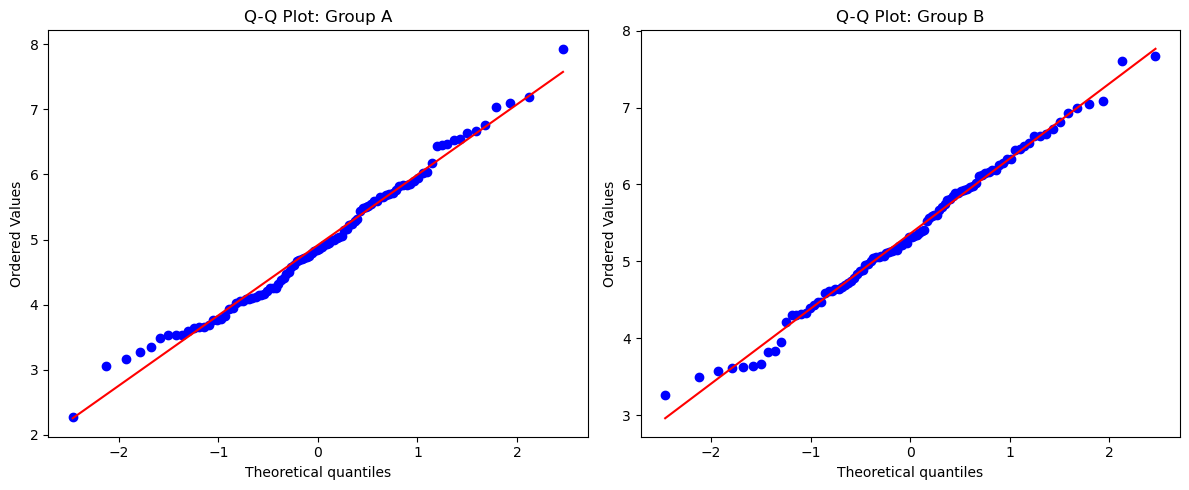

In [21]:
import matplotlib.pyplot as plt
import scipy.stats as stats

def qq_plot_normality(config, df):
    """
    Generates Q-Q plots to visually assess normality.

    - For one-sample: plots entire dataset
    - For two-sample: plots each group separately
    """

    print("\n📊 Step: Visual Normality Check using Q-Q Plot")
    print("If points fall approximately along the straight line → data is likely normal.\n")

    group_count = config['group_count']
    relationship = config['group_relationship']
    outcome = config['outcome_type']

    if outcome != 'continuous':
        print(f"⚠️ Skipping: Outcome type = `{outcome}` → Q-Q plot not applicable.")
        return

    if group_count == 'one-sample':
        plt.figure(figsize=(6, 6))
        stats.probplot(df['value'], dist="norm", plot=plt)
        plt.title("Q-Q Plot (One-Sample)")
        plt.show()

    elif group_count == 'two-sample':
        if relationship == 'independent':
            a = df[df['group'] == 'A']['value']
            b = df[df['group'] == 'B']['value']
        elif relationship == 'paired':
            a = df['group_A']
            b = df['group_B']
        else:
            print("❌ Invalid group relationship.")
            return

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        stats.probplot(a, dist="norm", plot=axes[0])
        axes[0].set_title("Q-Q Plot: Group A")

        stats.probplot(b, dist="norm", plot=axes[1])
        axes[1].set_title("Q-Q Plot: Group B")

        plt.tight_layout()
        plt.show()

    else:
        print("❌ Unsupported group count.")

qq_plot_normality(config, df)


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="check-variance"></a>
#### 📏 Check Variance

<details><summary><strong>📖 Equal Variance Check (Click to Expand)</strong></summary>

##### 📘 Why Are We Checking for Equal Variance?

When comparing **two independent groups** using a **parametric test** (like a two-sample t-test),  
we assume that both groups have **equal variances** — this is called the **homogeneity of variance** assumption.

Failing to meet this assumption can lead to incorrect conclusions if the wrong test is applied.

---

##### 🧪 Test Used: **Levene’s Test**

Levene’s Test checks whether the **spread (variance)** of values is roughly the same in both groups.

- **Null Hypothesis (H₀)**: Variance in Group A = Variance in Group B  
- **Alternative Hypothesis (H₁)**: Variances are different between the groups

---

##### 🧠 Interpretation:

- **p > 0.05** → Fail to reject H₀ → Variances are **likely equal** ✅  
- **p < 0.05** → Reject H₀ → Variances are **likely unequal** ⚠️

---

##### ✅ When Should You Check This?

- ✔️ Check **only** when:
  - You’re comparing **two groups**
  - The groups are **independent**
  - The outcome is **continuous**

- ❌ Don’t check if:
  - The test is **one-sample**
  - The groups are **paired** (since variance of differences is what matters)

</details>

In [13]:
def infer_variance_equality(config, df):
    """
    Infers whether the variances across two independent groups are equal using Levene's test.

    This function:
    - Checks if the variance assumption is relevant based on config
    - Runs Levene’s test to compare the variances of Group A and Group B
    - Updates the 'variance_equal' key in the config as 'equal', 'unequal', or 'NA'
    - Logs interpretation of the test result

    Parameters:
    -----------
    config : dict
        Configuration dictionary containing 'group_count' and 'group_relationship'
    df : pandas.DataFrame
        Input dataframe containing 'group' and 'value' columns

    Returns:
    --------
    dict
        Updated config dictionary with the 'variance_equal' key set
    """
    print("\n📏 **Step: Infer Equality of Variance Across Groups**")

    # Skip if not applicable
    if config['group_count'] != 'two-sample' or config['group_relationship'] != 'independent':
        print("⚠️ Skipping variance check: Only applicable for two-sample independent tests.")
        config['variance_equal'] = 'NA'
        return config

    print("📘 We're checking if the spread (variance) of the outcome variable is similar across groups A and B.")
    print("   This is important for choosing between a **pooled t-test** vs **Welch’s t-test**.")
    print("🔬 Test Used: Levene’s Test for Equal Variance")
    print("   H₀: Variance in Group A = Variance in Group B")
    print("   H₁: Variances are different")

    # Extract data
    a = df[df['group'] == 'A']['value']
    b = df[df['group'] == 'B']['value']

    # Run Levene's test
    stat, p = levene(a, b)
    print(f"\n📊 Levene’s Test Result:")
    print(f"• Test Statistic = {stat:.4f}")
    print(f"• p-value        = {p:.4f}")

    if p > 0.05:
        print("✅ Fail to reject H₀ → Variances appear equal across groups")
        config['variance_equal'] = 'equal'
    else:
        print("⚠️ Reject H₀ → Variances appear unequal")
        config['variance_equal'] = 'unequal'

    print(f"\n📦 Final Decision → config['variance_equal'] = `{config['variance_equal']}`")
    display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
    return config

config = infer_variance_equality(config, df)


📏 **Step: Infer Equality of Variance Across Groups**
📘 We're checking if the spread (variance) of the outcome variable is similar across groups A and B.
   This is important for choosing between a **pooled t-test** vs **Welch’s t-test**.
🔬 Test Used: Levene’s Test for Equal Variance
   H₀: Variance in Group A = Variance in Group B
   H₁: Variances are different

📊 Levene’s Test Result:
• Test Statistic = 1.0751
• p-value        = 0.3011
✅ Fail to reject H₀ → Variances appear equal across groups

📦 Final Decision → config['variance_equal'] = `equal`


In [14]:
pretty_json(config)
print_config_summary(config)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type            : continuous
🔸 Group Relationship      : independent
🔸 Group Count             : two-sample
🔸 Distribution of Outcome : normal
🔸 Equal Variance          : equal
🔸 Parametric Test         : None
🔸 Tail Type               : two-tailed
🔸 Significance Level α    : 0.05

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="infer-parametric"></a>
#### 📏 Infer Parametric Flag

<details><summary><strong>📖 Parametric vs Non-Parametric (Click to Expand)</strong></summary>

##### 📘 What Does "Parametric" Mean?

A **parametric test** assumes that the data follows a known distribution — typically a **normal distribution**.

These tests also often assume:
- Equal variances between groups (for two-sample cases)
- Independent samples

When those assumptions are met, parametric tests are **more powerful** (i.e., they detect real effects more easily).

---

##### 🔁 What Happens If Assumptions Don’t Hold?

You should use a **non-parametric test** — these don’t rely on strong distributional assumptions and are more robust, especially for small sample sizes or skewed data.

Examples:
| Parametric Test          | Non-Parametric Alternative       |
|--------------------------|----------------------------------|
| Two-sample t-test        | Mann-Whitney U test              |
| Paired t-test            | Wilcoxon Signed-Rank test        |
| ANOVA                    | Kruskal-Wallis test              |

---

##### 🧠 How We Decide Here

In our pipeline, a test is **parametric** only if:

- The outcome variable is **continuous**
- The data is **normally distributed**
- The variance is **equal**, if applicable (or marked `"NA"` for paired designs)

If these aren’t all true, we default to a non-parametric test.

</details>

In [15]:
def infer_parametric_flag(config):
    """
    Infers whether a parametric or non-parametric test should be used based on the config.

    This function:
    - Applies logic based on distribution and variance assumptions
    - Sets the 'parametric' key in the config to True, False, or 'NA'
    - Prints reasoning for transparency and learning

    Parameters:
    -----------
    config : dict
        Configuration dictionary containing 'outcome_type', 'distribution', and 'variance_equal'

    Returns:
    --------
    dict
        Updated config dictionary with the 'parametric' key populated
    """

    print("\n📏 Step: Decide Between Parametric vs Non-Parametric Approach")

    if config['outcome_type'] != 'continuous':
        print(f"⚠️ Skipping: Outcome type = `{config['outcome_type']}` → Parametric logic not applicable.")
        config['parametric'] = 'NA'
        return config

    is_normal = config['distribution'] == 'normal'
    is_equal_var = config['variance_equal'] in ['equal', 'NA']  # NA = not required for paired

    print(f"🔍 Outcome type             = `{config['outcome_type']}`")
    print(f"🔍 Distribution of outcome  = `{config['distribution']}`")
    print(f"🔍 Variance equal flag      = `{config['variance_equal']}`")

    if is_normal and is_equal_var:
        print("✅ Conditions met → Proceeding with a parametric test (e.g., t-test)")
        config['parametric'] = True
    else:
        print("⚠️ One or more assumptions violated → Using non-parametric alternative")
        config['parametric'] = False

    print(f"\n📦 Final Decision → config['parametric'] = `{config['parametric']}`")
    display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))

    return config

config = infer_parametric_flag(config)


📏 Step: Decide Between Parametric vs Non-Parametric Approach
🔍 Outcome type             = `continuous`
🔍 Distribution of outcome  = `normal`
🔍 Variance equal flag      = `equal`
✅ Conditions met → Proceeding with a parametric test (e.g., t-test)

📦 Final Decision → config['parametric'] = `True`


In [16]:
pretty_json(config)
print_config_summary(config)

📋 Hypothesis Test Configuration Summary

🔸 Outcome Type            : continuous
🔸 Group Relationship      : independent
🔸 Group Count             : two-sample
🔸 Distribution of Outcome : normal
🔸 Equal Variance          : equal
🔸 Parametric Test         : True
🔸 Tail Type               : two-tailed
🔸 Significance Level α    : 0.05

🧠 Inference Summary:
→ Comparing two independent groups (A vs B).


[Back to the top](#table-of-contents)
___


<a id="hypothesis-testing"></a>
<h1>🧪 Hypothesis Testing</h1>

<a id="determine-test"></a>
#### 🧭 Determine Test

<details><summary><strong>📖 How We Select the Right Statistical Test (Click to Expand)</strong></summary>

##### 🧠 What Are We Doing Here?

Based on all the configuration values you’ve either set or inferred (`outcome_type`, `group_relationship`, `distribution`, etc),  
we determine **which statistical test is most appropriate** for your hypothesis.

This is the decision engine of the pipeline.

---

##### ⚙️ How the Logic Works

We go through structured rules based on:

| Config Field           | What it Affects                     |
|------------------------|-------------------------------------|
| `outcome_type`         | Binary / continuous / categorical   |
| `group_count`          | One-sample / two-sample / multi     |
| `group_relationship`   | Independent or paired               |
| `distribution`         | Normal or non-normal                |
| `variance_equal`       | Determines pooled vs Welch’s t-test |
| `parametric`           | Whether to use parametric approach  |

---

##### 🧪 Example Mappings:

| Scenario                                             | Selected Test               |
|------------------------------------------------------|-----------------------------|
| Continuous, 2 groups, normal, equal variance         | Two-sample t-test (pooled)  |
| Continuous, 2 groups, non-normal                     | Mann-Whitney U              |
| Binary, 2 groups, independent                        | Proportions z-test          |
| Continuous, paired, non-normal                      | Wilcoxon Signed-Rank        |
| 3+ groups, categorical outcome                       | Chi-square test             |

</details>


<details><summary><strong>📖 Test Selection Matrix (Click to Expand)</strong></summary>

<table>
  <thead>
    <tr>
      <th>#</th>
      <th>💼 Example Business Problem</th>
      <th>📊 Outcome Variable Type</th>
      <th>📈 Outcome Distribution</th>
      <th>👥 Group Count</th>
      <th>🔗 Groups Type</th>
      <th>✅ Recommended Test</th>
      <th>📝 Notes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>Is average order value different from $50?</td>
      <td>Continuous</td>
      <td>Normal</td>
      <td>One-Sample</td>
      <td><em>Not Applicable</em></td>
      <td>One-sample t-test</td>
      <td><em>-</em></td>
    </tr>
    <tr>
      <td>2</td>
      <td>Do users who saw recs spend more time on site?</td>
      <td>Continuous</td>
      <td>Normal</td>
      <td>Two-Sample</td>
      <td>Independent</td>
      <td>Two-sample t-test</td>
      <td><em>Use if variances are equal; Welch’s t-test if not</em></td>
    </tr>
    <tr>
      <td>3</td>
      <td>Did users spend more after redesign?</td>
      <td>Continuous</td>
      <td>Normal</td>
      <td>Two-Sample</td>
      <td>Paired</td>
      <td>Paired t-test</td>
      <td><em>Use only if paired differences are roughly Normal</em></td>
    </tr>
    <tr>
      <td>4</td>
      <td>Does time spent differ across A/B/C?</td>
      <td>Continuous</td>
      <td>Normal</td>
      <td>Multi-Sample (3+)</td>
      <td>Independent</td>
      <td>ANOVA</td>
      <td><em>Use Welch ANOVA if group variances differ</em></td>
    </tr>
    <tr>
      <td>5</td>
      <td>Is average order value different from $50 (skewed)?</td>
      <td>Continuous</td>
      <td>Non-Normal</td>
      <td>One-Sample</td>
      <td><em>Not Applicable</em></td>
      <td>Wilcoxon Signed-Rank Test</td>
      <td><em>Use when normality is violated; tests median. Sign Test is an alternative with fewer assumptions</em></td>
    </tr>
    <tr>
      <td>6</td>
      <td>Is revenue different between coupon A vs B?</td>
      <td>Continuous</td>
      <td>Non-Normal</td>
      <td>Two-Sample</td>
      <td>Independent</td>
      <td>Mann-Whitney U test</td>
      <td><em>Use when data is skewed or has outliers</em></td>
    </tr>
    <tr>
      <td>7</td>
      <td>Did time on site change (skewed)?</td>
      <td>Continuous</td>
      <td>Non-Normal</td>
      <td>Two-Sample</td>
      <td>Paired</td>
      <td>Wilcoxon signed-rank test</td>
      <td><em>For paired non-normal distributions</em></td>
    </tr>
    <tr>
      <td>8</td>
      <td>Does spend differ across segments?</td>
      <td>Continuous</td>
      <td>Non-Normal</td>
      <td>Multi-Sample (3+)</td>
      <td>Independent</td>
      <td>Kruskal-Wallis test</td>
      <td><em>Non-parametric version of ANOVA</em></td>
    </tr>
    <tr>
      <td>9</td>
      <td>Is conversion rate different from 10%?</td>
      <td>Binary</td>
      <td><em>Not Applicable</em></td>
      <td>One-Sample</td>
      <td><em>Not Applicable</em></td>
      <td>One-proportion z-test</td>
      <td><em>Use binomial exact test if sample size is small</em></td>
    </tr>
    <tr>
      <td>10</td>
      <td>Does new CTA improve conversion?</td>
      <td>Binary</td>
      <td><em>Not Applicable</em></td>
      <td>Two-Sample</td>
      <td>Independent</td>
      <td>Proportions z-test</td>
      <td><em>Use when counts are raw; chi-square for independence. Fisher’s Exact if expected counts are low</em></td>
    </tr>
    <tr>
      <td>11</td>
      <td>Do users convert more after badges?</td>
      <td>Binary</td>
      <td><em>Not Applicable</em></td>
      <td>Two-Sample</td>
      <td>Paired</td>
      <td>McNemar’s test</td>
      <td><em>Used for 2×2 paired binary outcomes</em></td>
    </tr>
    <tr>
      <td>12</td>
      <td>Do plan choices differ across layout options?</td>
      <td>Categorical</td>
      <td><em>Not Applicable</em></td>
      <td>Multi-Sample (3+)</td>
      <td>Independent</td>
      <td>Chi-square test</td>
      <td><em>Requires expected frequency ≥5 in each cell. Use Fisher’s Exact if assumption fails</em></td>
    </tr>
    <tr>
      <td>13</td>
      <td>Do users add more items to cart?</td>
      <td>Count</td>
      <td>Poisson</td>
      <td>Two-Sample</td>
      <td>Independent</td>
      <td>Poisson / NB test</td>
      <td><em>Use Negative Binomial if variance > mean</em></td>
    </tr>
    <tr>
      <td>14</td>
      <td>Is effect still significant after adjusting for device & region?</td>
      <td>Any</td>
      <td><em>Not Applicable</em></td>
      <td>Any</td>
      <td>Any</td>
      <td>Regression (linear / logistic)</td>
      <td><em>Use to control for covariates / confounders</em></td>
    </tr>
    <tr>
      <td>15</td>
      <td>What’s the probability that B beats A?</td>
      <td>Any</td>
      <td><em>Not Applicable</em></td>
      <td>Two-Sample</td>
      <td>Any</td>
      <td>Bayesian A/B test</td>
      <td><em>Posterior probability; no p-value</em></td>
    </tr>
    <tr>
      <td>16</td>
      <td>Is observed lift statistically rare?</td>
      <td>Any</td>
      <td><em>Not Applicable</em></td>
      <td>Two-Sample</td>
      <td>Any</td>
      <td>Permutation / Bootstrap</td>
      <td><em>Use when parametric assumptions are violated</em></td>
    </tr>
  </tbody>
</table>

</details>


<details>
<summary><strong>📖 Test Selection FlowChart (Click to Expand)</strong></summary>

<pre>
[What is your outcome variable type?]  
  |
  +--> 📏 Continuous
  |     |
  |     +--> Is the outcome distribution normal?
  |           |
  |           +--> ✅ Yes
  |           |     |
  |           |     +--> 👥 Group Count = One-Sample ----------> 🧪 One-sample t-test
  |           |     +--> 👥 Group Count = Two-Sample
  |           |     |     +--> 🔗 Groups Type = Independent ---> 🧪 Two-sample t-test
  |           |     |     +--> 🔗 Groups Type = Paired --------> 🧪 Paired t-test
  |           |     +--> 👥 Group Count = Multi-Sample (3+) ---> 🧪 ANOVA
  |           |
  |           +--> ❌ No (Non-Normal)
  |                 |
  |                 +--> 👥 Group Count = One-Sample ----------> 🧪 Wilcoxon Signed-Rank Test
  |                 +--> 👥 Group Count = Two-Sample
  |                 |     +--> 🔗 Groups Type = Independent ---> 🧪 Mann-Whitney U Test
  |                 |     +--> 🔗 Groups Type = Paired --------> 🧪 Wilcoxon Signed-Rank Test
  |                 +--> 👥 Group Count = Multi-Sample (3+) ---> 🧪 Kruskal-Wallis Test
  |
  +--> ⚪ Binary
  |     |
  |     +--> 👥 Group Count = One-Sample -----------------------> 🧪 One-proportion z-test
  |     +--> 👥 Group Count = Two-Sample
  |     |     +--> 🔗 Groups Type = Independent ---------------> 🧪 Proportions z-test
  |     |     +--> 🔗 Groups Type = Paired --------------------> 🧪 McNemar’s Test
  |
  +--> 🟪 Categorical
  |     |
  |     +--> 👥 Group Count = Multi-Sample (3+) ---------------> 🧪 Chi-square Test
  |
  +--> 🔢 Count
  |     |
  |     +--> Distribution = Poisson
  |           +--> 👥 Group Count = Two-Sample ---------------> 🧪 Poisson or Negative Binomial Test
  |
  +--> 🧠 Any
        |
        +--> Want to control for covariates? -------------> 📉 Regression (Linear or Logistic)
        +--> Prefer probability over p-values? -----------> 📊 Bayesian A/B Test
        +--> Assumptions violated / custom metric? -------> 🔁 Permutation or Bootstrap
</pre>

</details>

In [17]:
def determine_test_to_run(config):
    """
    Determines the appropriate statistical test based on the provided configuration.

    This function:
    - Maps outcome type, group count, group relationship, distribution, and parametric flags
    to the correct hypothesis test
    - Prints the reasoning and selected test
    - Returns a string identifier for the test to be used

    Parameters:
    -----------
    config : dict
        A dictionary containing keys like 'outcome_type', 'group_count', 'group_relationship',
        'distribution', 'variance_equal', and 'parametric'.

    Returns:
    --------
    str
        A string representing the selected test name (e.g., 'two_sample_ttest_welch', 'mcnemar', etc.)
    """

    print("\n🧭 Step: Determine Which Statistical Test to Use")
    
    outcome = config['outcome_type']
    group_rel = config['group_relationship']
    group_count = config['group_count']
    dist = config['distribution']
    equal_var = config['variance_equal']
    parametric = config['parametric']

    print("📦 Inputs:")
    print(f"• Outcome Type         = `{outcome}`")
    print(f"• Group Count          = `{group_count}`")
    print(f"• Group Relationship   = `{group_rel}`")
    print(f"• Distribution         = `{dist}`")
    print(f"• Equal Variance       = `{equal_var}`")
    print(f"• Parametric Flag      = `{parametric}`")

    print("\n🔍 Matching against known test cases...")

    # One-sample
    if group_count == 'one-sample':
        if outcome == 'continuous':
            test = 'one_sample_ttest' if dist == 'normal' else 'one_sample_wilcoxon'
        elif outcome == 'binary':
            test = 'one_proportion_ztest'
        else:
            test = 'test_not_found'

    # Two-sample independent
    elif group_count == 'two-sample' and group_rel == 'independent':
        if outcome == 'continuous':
            if parametric:
                test = 'two_sample_ttest_pooled' if equal_var == 'equal' else 'two_sample_ttest_welch'
            else:
                test = 'mann_whitney_u'
        elif outcome == 'binary':
            test = 'two_proportion_ztest'
        elif outcome == 'categorical':
            test = 'chi_square'
        else:
            test = 'test_not_found'

    # Two-sample paired
    elif group_count == 'two-sample' and group_rel == 'paired':
        if outcome == 'continuous':
            test = 'paired_ttest' if parametric else 'wilcoxon_signed_rank'
        elif outcome == 'binary':
            test = 'mcnemar'
        else:
            test = 'test_not_found'

    # Multi-group
    elif group_count == 'multi-sample':
        if outcome == 'continuous':
            test = 'anova' if dist == 'normal' else 'kruskal_wallis'
        elif outcome == 'categorical':
            test = 'chi_square'
        else:
            test = 'test_not_found'

    # Count data
    elif outcome == 'count':
        test = 'poisson_test'

    else:
        test = 'test_not_found'

    print(f"\n✅ Selected Test: `{test}`")
    display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
    return test
determine_test_to_run(config)



🧭 Step: Determine Which Statistical Test to Use
📦 Inputs:
• Outcome Type         = `continuous`
• Group Count          = `two-sample`
• Group Relationship   = `independent`
• Distribution         = `normal`
• Equal Variance       = `equal`
• Parametric Flag      = `True`

🔍 Matching against known test cases...

✅ Selected Test: `two_sample_ttest_pooled`


'two_sample_ttest_pooled'

<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="print-hypothesis"></a>
#### 🧠 Print Hypothesis

<details><summary><strong>📖 Hypothesis Structure & Interpretation (Click to Expand)</strong></summary>

##### 📘 What Are We Doing Here?

This step generates a **formal hypothesis statement** for the selected test.

Every statistical test is built around two competing ideas:

- **H₀ (Null Hypothesis)** → The “status quo”. There is **no effect**, **no difference**, or **no association**.
- **H₁ (Alternative Hypothesis)** → There **is** an effect, difference, or relationship.

---

##### 🧪 Examples of Hypothesis Pairs

| Test Type                | Null Hypothesis (H₀)                        | Alternative (H₁)                            |
|--------------------------|---------------------------------------------|---------------------------------------------|
| Two-sample t-test        | Mean A = Mean B                             | Mean A ≠ Mean B (or A > B, A < B)           |
| One-sample t-test        | Mean = reference value                      | Mean ≠ reference value                      |
| Proportions z-test       | Prop A = Prop B                             | Prop A ≠ Prop B (or A > B)                  |
| ANOVA                    | All group means are equal                   | At least one group mean is different        |
| Chi-square test          | Category distributions are the same         | Distributions differ across groups          |
| McNemar’s test           | Before = After                              | Before ≠ After                              |

---

##### 📏 One-Tailed vs Two-Tailed

- **Two-tailed**: Tests for *any* difference (≠)
- **One-tailed**: Tests for *directional* difference (> or <)

---

##### 🧠 Why Does This Matter?

Framing a clear hypothesis helps:
- Justify the test selection
- Interpret results correctly
- Communicate with non-technical stakeholders
- Align on **what question** the analysis is really answering

</details>

In [18]:
def print_hypothesis_statement(config):
    """
    Prints the null and alternative hypothesis statements based on the selected test and tail type.

    This function:
    - Uses the provided config to determine which statistical test applies
    - Displays clear H₀ and H₁ statements tailored to the test type and direction (one-tailed vs two-tailed)
    - Aims to bridge technical and business understanding of what is being tested

    Parameters:
    -----------
    config : dict
        Configuration dictionary containing at least 'tail_type' and the required fields to determine the test

    Returns:
    --------
    None
        Prints formatted hypothesis statements directly to output
    """

    print("\n🧠 Step: Generate Hypothesis Statement")

    test = determine_test_to_run(config)
    tail = config['tail_type']

    print(f"🔍 Selected Test        : `{test}`")
    print(f"🔍 Tail Type            : `{tail}`\n")

    print("📜 Hypothesis Statement:")

    if test == 'one_sample_ttest':
        print("• H₀: The sample mean equals the reference value.")
        print("• H₁:", "The sample mean is different from the reference." if tail == 'two-tailed' else "The sample mean is greater/less than the reference.")

    elif test == 'one_proportion_ztest':
        print("• H₀: The sample proportion equals the baseline rate.")
        print("• H₁:", "The sample proportion is different from the baseline." if tail == 'two-tailed' else "The sample proportion is greater/less than the baseline.")

    elif test in ['two_sample_ttest_pooled', 'two_sample_ttest_welch', 'mann_whitney_u', 'two_proportion_ztest']:
        print("• H₀: The outcome (mean/proportion) is the same across groups A and B.")
        print("• H₁:", "The outcome differs between groups." if tail == 'two-tailed' else "Group B is greater/less than Group A.")

    elif test in ['paired_ttest', 'wilcoxon_signed_rank']:
        print("• H₀: The average difference between paired values (before vs after) is zero.")
        print("• H₁:", "There is a difference in paired values." if tail == 'two-tailed' else "After is greater/less than before.")

    elif test == 'mcnemar':
        print("• H₀: Proportion of success is the same before and after.")
        print("• H₁: Proportion of success changed after treatment.")

    elif test in ['anova', 'kruskal_wallis']:
        print("• H₀: All group means (or distributions) are equal.")
        print("• H₁: At least one group differs.")

    elif test == 'chi_square':
        print("• H₀: Category distributions are the same across groups.")
        print("• H₁: At least one category behaves differently.")

    elif test == 'poisson_test':
        print("• H₀: The count rate (λ) is the same across groups.")
        print("• H₁: Count rate differs between groups.")

    elif test == 'bayesian_ab':
        print("• Posterior: Probability that Group B is better than Group A.")

    elif test == 'permutation_test':
        print("• H₀: Observed difference is due to chance.")
        print("• H₁: Observed difference is unlikely under random shuffling.")

    else:
        print(f"❓ Unable to generate hypothesis statement for test: `{test}`")

    display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
        
print_hypothesis_statement(config)


🧠 Step: Generate Hypothesis Statement

🧭 Step: Determine Which Statistical Test to Use
📦 Inputs:
• Outcome Type         = `continuous`
• Group Count          = `two-sample`
• Group Relationship   = `independent`
• Distribution         = `normal`
• Equal Variance       = `equal`
• Parametric Flag      = `True`

🔍 Matching against known test cases...

✅ Selected Test: `two_sample_ttest_pooled`


🔍 Selected Test        : `two_sample_ttest_pooled`
🔍 Tail Type            : `two-tailed`

📜 Hypothesis Statement:
• H₀: The outcome (mean/proportion) is the same across groups A and B.
• H₁: The outcome differs between groups.


<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="run-test"></a>
#### 🧪 Run Hypothesis Test

<details><summary><strong>📖 Running the Hypothesis Test (Click to Expand)</strong></summary>

##### 🧠 What Happens in This Step?

This function takes in your final config + dataset and **executes the appropriate test** — outputting:

- The test statistic (e.g., t, z, chi², U, F)
- The p-value
- Whether the result is statistically significant

##### 🧪 Interpreting the Output

| Field         | What It Means |
|---------------|----------------|
| `statistic`   | The test result (e.g., t-score, chi-square, etc) |
| `p_value`     | Probability of seeing this result by chance |
| `significant` | `True` if `p < alpha` (reject H₀), else `False` |
| `alpha`       | The pre-defined significance threshold (typically 0.05) |

##### 📏 Significance Logic

- If **p < alpha** → reject the null hypothesis  
- If **p ≥ alpha** → fail to reject the null

##### ⚠️ Robustness

The function handles different test types:
- Parametric (e.g., t-tests, ANOVA)
- Non-parametric (e.g., Wilcoxon, Mann-Whitney)
- Binary proportions (e.g., z-test, McNemar)
- Multi-group (e.g., ANOVA, chi-square)
- Even fallback with `test_not_found`

</details>

In [19]:
def run_hypothesis_test(config, df):
    """
    Runs the appropriate hypothesis test based on the provided configuration and dataset.

    This function:
    - Identifies the correct test using `determine_test_to_run(config)`
    - Executes the corresponding statistical test (e.g., t-test, z-test, Mann-Whitney, ANOVA, etc.)
    - Prints a guided explanation of inputs, selected test, test statistic, p-value, and business interpretation
    - Returns a result dictionary with test details and significance flag

    Parameters:
    -----------
    config : dict
        Dictionary specifying test configuration (e.g., outcome_type, group_relationship, parametric, etc.)
    df : pandas.DataFrame
        Input dataset containing outcome values (and group labels if applicable)

    Returns:
    --------
    dict
        {
            'test': str,              # Name of the statistical test run
            'statistic': float,       # Test statistic
            'p_value': float,         # P-value of the test
            'significant': bool,      # True if p < alpha
            'alpha': float            # Significance threshold used
        }
    """
    print("\n🧪 Step: Run Hypothesis Test")

    test_name = determine_test_to_run(config)
    alpha = config.get('alpha', 0.05)

    print(f"\n🧭 Step: Determine Which Statistical Test to Use")
    print("📦 Inputs:")
    print(f"• Outcome Type         = `{config['outcome_type']}`")
    print(f"• Group Count          = `{config['group_count']}`")
    print(f"• Group Relationship   = `{config['group_relationship']}`")
    print(f"• Distribution         = `{config['distribution']}`")
    print(f"• Equal Variance       = `{config['variance_equal']}`")
    print(f"• Parametric Flag      = `{config['parametric']}`")

    print(f"\n🔍 Matching against known test cases...")
    print(f"✅ Selected Test        : `{test_name}`")
    print(f"🔍 Significance Threshold (α) : {alpha:.2f}\n")

    result = {
        'test': test_name,
        'statistic': None,
        'p_value': None,
        'significant': None,
        'alpha': alpha
    }

    try:
        print("🚀 Executing statistical test...")

        # --- Run appropriate test ---
        if test_name == 'one_sample_ttest':
            stat, p = ttest_1samp(df['value'], config['population_mean'])

        elif test_name == 'one_sample_wilcoxon':
            stat, p = wilcoxon(df['value'] - config['population_mean'])

        elif test_name == 'one_proportion_ztest':
            x = np.sum(df['value'])
            n = len(df)
            stat, p = proportions_ztest(x, n, value=config['population_mean'])

        elif test_name == 'two_sample_ttest_pooled':
            a = df[df['group'] == 'A']['value']
            b = df[df['group'] == 'B']['value']
            stat, p = ttest_ind(a, b, equal_var=True)

        elif test_name == 'two_sample_ttest_welch':
            a = df[df['group'] == 'A']['value']
            b = df[df['group'] == 'B']['value']
            stat, p = ttest_ind(a, b, equal_var=False)

        elif test_name == 'mann_whitney_u':
            a = df[df['group'] == 'A']['value']
            b = df[df['group'] == 'B']['value']
            stat, p = mannwhitneyu(a, b, alternative='two-sided')

        elif test_name == 'paired_ttest':
            stat, p = ttest_rel(df['group_A'], df['group_B'])

        elif test_name == 'wilcoxon_signed_rank':
            stat, p = wilcoxon(df['group_A'], df['group_B'])

        elif test_name == 'two_proportion_ztest':
            a = df[df['group'] == 'A']['value']
            b = df[df['group'] == 'B']['value']
            counts = [np.sum(a), np.sum(b)]
            nobs = [len(a), len(b)]
            stat, p = proportions_ztest(count=counts, nobs=nobs)

        elif test_name == 'mcnemar':
            before = df['group_A']
            after = df['group_B']
            both = np.sum((before == 1) & (after == 1))
            before_only = np.sum((before == 1) & (after == 0))
            after_only = np.sum((before == 0) & (after == 1))
            neither = np.sum((before == 0) & (after == 0))
            table = np.array([[both, before_only], [after_only, neither]])
            stat, p = chi2_contingency(table, correction=True)[:2]

        elif test_name == 'anova':
            groups = [g['value'].values for _, g in df.groupby('group')]
            stat, p = f_oneway(*groups)

        elif test_name == 'kruskal_wallis':
            groups = [g['value'].values for _, g in df.groupby('group')]
            stat, p = kruskal(*groups)

        elif test_name == 'chi_square':
            contingency = pd.crosstab(df['group'], df['value'])
            stat, p, _, _ = chi2_contingency(contingency)

        else:
            warnings.warn(f"❌ Test not implemented: `{test_name}`")
            return result

        result['statistic'] = stat
        result['p_value'] = p
        result['significant'] = p < alpha

        # --- Final Output Block ---
        print(f"\n📊 Test Summary: {test_name.replace('_', ' ').title()}")

        print("\n🧪 Technical Result")
        print(f"• Test Statistic     = {stat:.4f}")
        print(f"• P-value            = {p:.4f}")
        print(f"• Alpha (α)          = {alpha:.2f}")

        if p < alpha:
            print(f"• Conclusion         = ✅ Statistically significant → Reject H₀")
            print("\n📈 Interpretation")
            print("• The observed difference is unlikely due to random variation.")

            # Business Interpretation
            if config['group_count'] == 'two-sample' and config['group_relationship'] == 'independent':
                a = df[df['group'] == 'A']['value']
                b = df[df['group'] == 'B']['value']
                mean_a = np.mean(a)
                mean_b = np.mean(b)
                lift = mean_b - mean_a
                pct_lift = (lift / mean_a) * 100

                label = "mean" if config['outcome_type'] == 'continuous' else 'conversion rate'
                print("\n💼 Business Insight")
                print(f"• Group A {label} = {mean_a:.2f}")
                print(f"• Group B {label} = {mean_b:.2f}")
                print(f"• Lift = {lift:.2f} ({pct_lift:+.2f}%)")

                if lift > 0:
                    print("🏆 Group B outperforms Group A — and the effect is statistically significant.")
                else:
                    print("📉 Group B underperforms Group A — and the drop is statistically significant.")
        else:
            print(f"• Conclusion         = ❌ Not statistically significant → Fail to reject H₀")
            print("\n📈 Interpretation")
            print("• The observed difference could be explained by randomness.")
            print("\n💼 Business Insight")
            print("• No strong evidence of difference between the groups.")

        display(HTML("<hr style='border: none; height: 1px; background-color: #ddd;' />"))
        return result

    except Exception as e:
        warnings.warn(f"🚨 Error during test execution: {e}")
        return result


In [20]:
_ = run_hypothesis_test(config, df)


🧪 Step: Run Hypothesis Test

🧭 Step: Determine Which Statistical Test to Use
📦 Inputs:
• Outcome Type         = `continuous`
• Group Count          = `two-sample`
• Group Relationship   = `independent`
• Distribution         = `normal`
• Equal Variance       = `equal`
• Parametric Flag      = `True`

🔍 Matching against known test cases...

✅ Selected Test: `two_sample_ttest_pooled`



🧭 Step: Determine Which Statistical Test to Use
📦 Inputs:
• Outcome Type         = `continuous`
• Group Count          = `two-sample`
• Group Relationship   = `independent`
• Distribution         = `normal`
• Equal Variance       = `equal`
• Parametric Flag      = `True`

🔍 Matching against known test cases...
✅ Selected Test        : `two_sample_ttest_pooled`
🔍 Significance Threshold (α) : 0.05

🚀 Executing statistical test...

📊 Test Summary: Two Sample Ttest Pooled

🧪 Technical Result
• Test Statistic     = -3.0942
• P-value            = 0.0023
• Alpha (α)          = 0.05
• Conclusion         = ✅ Statistically significant → Reject H₀

📈 Interpretation
• The observed difference is unlikely due to random variation.

💼 Business Insight
• Group A mean = 4.92
• Group B mean = 5.36
• Lift = 0.45 (+9.07%)
🏆 Group B outperforms Group A — and the effect is statistically significant.


[Back to the top](#table-of-contents)    
___
